In [1]:
!pip install transformers==4.40.2
!pip install datasets
!pip install evaluate


In [2]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [4]:
dataset["train"][0]


{'article': 'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don\'t think I\'ll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office char

Take sample from the whole dataset

In [5]:
train_data = dataset["train"].select(range(800))


Domain Filtering (Politics / Sports / Finance)

In [6]:
def classify_domain(text):
    text = text.lower()

    if any(word in text for word in ["election", "government", "president", "senate"]):
        return "Politics"

    elif any(word in text for word in ["match", "tournament", "goal", "league"]):
        return "Sports"

    elif any(word in text for word in ["market", "stock", "bank", "finance"]):
        return "Finance"

    else:
        return "Other"


In [7]:
domain_data = []

for sample in train_data:
    domain = classify_domain(sample["article"])
    if domain in ["Politics", "Sports", "Finance"]:
        domain_data.append({
            "article": sample["article"],
            "summary": sample["highlights"],
            "domain": domain
        })


In [8]:
import pandas as pd

df = pd.DataFrame(domain_data)
print(df["domain"].value_counts())


domain
Politics    396
Sports       96
Finance      51
Name: count, dtype: int64


balancing all (50,50,50)

In [9]:
politics_df = df[df["domain"] == "Politics"].head(50)
sports_df = df[df["domain"] == "Sports"].head(50)
finance_df = df[df["domain"] == "Finance"].head(50)

final_df = pd.concat([politics_df, sports_df, finance_df], ignore_index=True)

Now Loading Pre trained model from hugging face using Transformers


In [10]:
!pip uninstall -y transformers
!pip install transformers==4.40.2

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
  Using cached transformers-4.40.2-py3-none-any.whl.metadata (137 kB)
Using cached transformers-4.40.2-py3-none-any.whl (9.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.2 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.


Evaluation Phase

In [11]:
from transformers import pipeline
import torch
import time
import gc
import pandas as pd

device = -1 # Explicitly set device to -1 for CPU
print("Using device:", device)

Using device: -1


In [13]:
test_df = final_df.groupby("domain").head(5).reset_index(drop=True)
print(test_df["domain"].value_counts())


domain
Politics    5
Sports      5
Finance     5
Name: count, dtype: int64


In [26]:
results = []

model_names = [
    "facebook/bart-base",
    "t5-small",
    "t5-base",
    "google/pegasus-cnn_dailymail"
]

for model_name in model_names:
    print(f"Processing with model: {model_name}")
    summarizer = pipeline("summarization",
                          model=model_name,
                          device=device)

    for index, row in test_df.iterrows():

        article = row["article"][:800]  # Safe truncation
        reference = row["summary"]
        domain = row["domain"]

        start = time.time()

        output = summarizer(article,
                            max_length=120,
                            min_length=30,
                            truncation=True,
                            do_sample=False)

        end = time.time()

        results.append({
            "domain": domain,
            "model": model_name,
            "reference": reference,
            "generated_summary": output[0]["summary_text"],
            "inference_time": end - start
        })

    del summarizer
    gc.collect()

Processing with model: facebook/bart-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processing with model: t5-small


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Processing with model: google/pegasus-cnn_dailymail


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-cnn_dailymail and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df.head(20))

      domain               model  \
0   Politics  facebook/bart-base   
1   Politics  facebook/bart-base   
2   Politics  facebook/bart-base   
3   Politics  facebook/bart-base   
4   Politics  facebook/bart-base   
5     Sports  facebook/bart-base   
6     Sports  facebook/bart-base   
7     Sports  facebook/bart-base   
8     Sports  facebook/bart-base   
9     Sports  facebook/bart-base   
10   Finance  facebook/bart-base   
11   Finance  facebook/bart-base   
12   Finance  facebook/bart-base   
13   Finance  facebook/bart-base   
14   Finance  facebook/bart-base   
15  Politics            t5-small   
16  Politics            t5-small   
17  Politics            t5-small   
18  Politics            t5-small   
19  Politics            t5-small   

                                            reference  \
0   Mentally ill inmates in Miami are housed on th...   
1   Five small polyps found during procedure; "non...   
2   NEW: NFL chief, Atlanta Falcons owner critical...   
3   Aid workers

**Reasoning**:
Now that the summaries are generated and stored in `results_df`, the next step is to load the evaluation metrics (ROUGE and BERTScore) using the `evaluate` library, as per the original notebook's flow.



In [32]:
import evaluate

rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")


**Reasoning**:
With the evaluation metrics loaded, the next logical step is to iterate through the generated summaries in `results_df`, calculate the ROUGE, BERTScore, and compression ratio for each summary, and store these results in a new list, `evaluation_results`.



In [33]:
evaluation_results = []

for index, row in results_df.iterrows():

    generated = row["generated_summary"]
    reference = row["reference"]
    domain = row["domain"]
    model_name = row["model"]
    inference_time = row["inference_time"]

    # ROUGE
    rouge_scores = rouge.compute(
        predictions=[generated],
        references=[reference]
    )

    # BERTScore
    bert_scores = bertscore.compute(
        predictions=[generated],
        references=[reference],
        lang="en",
        device="cpu" # Explicitly set device to CPU to avoid CUDA memory issues
    )

    # Compression Ratio
    compression_ratio = len(generated.split()) / len(row["reference"].split())

    evaluation_results.append({
        "domain": domain,
        "model": model_name,
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "bertscore": bert_scores["f1"][0],
        "compression_ratio": compression_ratio,
        "inference_time": inference_time
    })


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Reasoning**:
The previous step successfully computed the evaluation metrics for all generated summaries, despite a warning. The next logical step is to convert the `evaluation_results` list into a pandas DataFrame and display its head to verify the calculated scores, following the original notebook's flow.



In [34]:
eval_df = pd.DataFrame(evaluation_results)
print(eval_df.head(5))

     domain               model    rouge1    rouge2    rougeL  bertscore  \
0  Politics  facebook/bart-base  0.340426  0.129496  0.184397   0.833678   
1  Politics  facebook/bart-base  0.290598  0.104348  0.188034   0.855449   
2  Politics  facebook/bart-base  0.328571  0.072464  0.171429   0.866939   
3  Politics  facebook/bart-base  0.239437  0.014286  0.126761   0.844698   
4  Politics  facebook/bart-base  0.532258  0.344262  0.290323   0.860463   

   compression_ratio  inference_time  
0           1.816327        9.847940  
1           3.444444        9.587758  
2           2.272727        9.751371  
3           1.880000       10.035366  
4           1.818182        9.935908  


**Reasoning**:
With the individual evaluation scores computed and stored in `eval_df`, the next step is to calculate the average scores for each domain and model, as this is the final evaluation step mentioned in the task description.



In [35]:
final_scores = eval_df.groupby(["domain", "model"]).mean().reset_index()
print(final_scores)

      domain                         model    rouge1    rouge2    rougeL  \
0    Finance            facebook/bart-base  0.305624  0.091643  0.174182   
1    Finance  google/pegasus-cnn_dailymail  0.341875  0.143137  0.273467   
2    Finance                       t5-base  0.340220  0.114587  0.240305   
3    Finance                      t5-small  0.295852  0.070856  0.178775   
4   Politics            facebook/bart-base  0.346258  0.132971  0.192189   
5   Politics  google/pegasus-cnn_dailymail  0.396384  0.180987  0.302869   
6   Politics                       t5-base  0.331953  0.118940  0.250948   
7   Politics                      t5-small  0.259410  0.073489  0.174792   
8     Sports            facebook/bart-base  0.349060  0.164195  0.226229   
9     Sports  google/pegasus-cnn_dailymail  0.457453  0.232993  0.360405   
10    Sports                       t5-base  0.403371  0.161739  0.271266   
11    Sports                      t5-small  0.388363  0.169158  0.272944   

    bertsco

Applying Topsis

In [38]:
import numpy as np

def manual_topsis(matrix, weights, criteria):
    """
    matrix: decision matrix (numpy array)
    weights: list of weights
    criteria: list of True (maximize) or False (minimize)
    """

    # Step 1: Normalize matrix
    norm_matrix = matrix / np.sqrt((matrix**2).sum(axis=0))

    # Step 2: Apply weights
    weighted_matrix = norm_matrix * weights

    # Step 3: Determine ideal and negative ideal solutions
    ideal = []
    negative_ideal = []

    for i in range(len(criteria)):
        if criteria[i]:  # maximize
            ideal.append(np.max(weighted_matrix[:, i]))
            negative_ideal.append(np.min(weighted_matrix[:, i]))
        else:  # minimize
            ideal.append(np.min(weighted_matrix[:, i]))
            negative_ideal.append(np.max(weighted_matrix[:, i]))

    ideal = np.array(ideal)
    negative_ideal = np.array(negative_ideal)

    # Step 4: Calculate distances
    distance_to_ideal = np.sqrt(((weighted_matrix - ideal)**2).sum(axis=1))
    distance_to_negative = np.sqrt(((weighted_matrix - negative_ideal)**2).sum(axis=1))

    # Step 5: Calculate TOPSIS score
    scores = distance_to_negative / (distance_to_ideal + distance_to_negative)

    return scores


In [39]:
weights = np.array([1,1,1,1,1,1])
weights = weights / weights.sum()

criteria = [True, True, True, True, False, False]


In [40]:
topsis_results = []

for domain in final_scores["domain"].unique():

    domain_data = final_scores[final_scores["domain"] == domain].copy()

    matrix = domain_data[[
        "rouge1",
        "rouge2",
        "rougeL",
        "bertscore",
        "compression_ratio",
        "inference_time"
    ]].values

    scores = manual_topsis(matrix, weights, criteria)

    domain_data["TOPSIS_score"] = scores
    domain_data["Rank"] = scores.argsort()[::-1] + 1

    topsis_results.append(domain_data)


In [41]:
topsis_df = pd.concat(topsis_results)
print(topsis_df.sort_values(["domain", "Rank"]))


      domain                         model    rouge1    rouge2    rougeL  \
2    Finance                       t5-base  0.340220  0.114587  0.240305   
3    Finance                      t5-small  0.295852  0.070856  0.178775   
0    Finance            facebook/bart-base  0.305624  0.091643  0.174182   
1    Finance  google/pegasus-cnn_dailymail  0.341875  0.143137  0.273467   
6   Politics                       t5-base  0.331953  0.118940  0.250948   
7   Politics                      t5-small  0.259410  0.073489  0.174792   
4   Politics            facebook/bart-base  0.346258  0.132971  0.192189   
5   Politics  google/pegasus-cnn_dailymail  0.396384  0.180987  0.302869   
11    Sports                      t5-small  0.388363  0.169158  0.272944   
10    Sports                       t5-base  0.403371  0.161739  0.271266   
9     Sports  google/pegasus-cnn_dailymail  0.457453  0.232993  0.360405   
8     Sports            facebook/bart-base  0.349060  0.164195  0.226229   

    bertsco

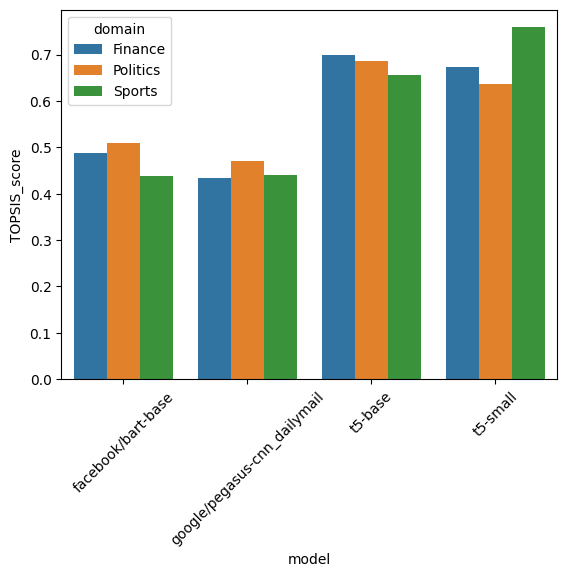

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=topsis_df, x="model", y="TOPSIS_score", hue="domain")
plt.xticks(rotation=45)
plt.show()
